# Homer Comparison

In [767]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.dates as mdates
from matplotlib.patches import Patch


In [768]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

directory = "homer/elite_test2.csv"   # update if the file lives elsewhere

def ts():
    """Timestamp string for filenames, e.g. 20260920_143005"""
    return datetime.now().strftime("%Y%m%d_%H%M%S")

In [769]:
# Row 1 = "sep=," Excel hint, row 2 = header, row 3 = units row
units_row = pd.read_csv(directory, skiprows=2, nrows=1, header=None).iloc[0].tolist()
df = pd.read_csv(directory, skiprows=[0, 2])
units = dict(zip(df.columns, units_row))

df["Time"] = pd.to_datetime(df["Time"], format="%m/%d/%Y %I:%M:%S %p")
df = df.set_index("Time")

print(df.shape)
display(df.head(3).T)

(8760, 28)


Time,2024-01-01 00:00:00,2024-01-01 01:00:00,2024-01-01 02:00:00
AC Primary Load,4.141122e-01,2.484673e-01,8.282244e-02
AC Primary Load Served,4.141122e-01,2.484673e-01,8.282244e-02
Deferrable Load Served,0.000000e+00,0.000000e+00,0.000000e+00
Deferrable Load Storage Level,0.000000e+00,0.000000e+00,0.000000e+00
Grid Power Price,3.000000e-01,3.000000e-01,3.000000e-01
Grid Sellback Rate,0.000000e+00,0.000000e+00,0.000000e+00
Grid Purchases,0.000000e+00,0.000000e+00,0.000000e+00
Total Electrical Load Served,4.141122e-01,2.484673e-01,8.282244e-02
Renewable Penetration,0.000000e+00,0.000000e+00,0.000000e+00
Unmet Electrical Load,0.000000e+00,0.000000e+00,0.000000e+00


In [770]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 8760 entries, 2024-01-01 00:00:00 to 2024-12-30 23:00:00
Data columns (total 28 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   AC Primary Load                                          8760 non-null   float64
 1   AC Primary Load Served                                   8760 non-null   float64
 2   Deferrable Load Served                                   8760 non-null   int64  
 3   Deferrable Load Storage Level                            8760 non-null   int64  
 4   Grid Power Price                                         8760 non-null   float64
 5   Grid Sellback Rate                                       8760 non-null   int64  
 6   Grid Purchases                                           8760 non-null   float64
 7   Total Electrical Load Served                             8760 non-null   float64
 8   Ren

In [771]:
summary = df.describe().T[["mean", "std", "min", "max"]]
summary.insert(0, "unit", pd.Series(units))
summary["n_unique"] = df.nunique()
summary["pct_zero"] = ((df == 0).mean() * 100).round(1)
display(summary.round(4))
print("Constant columns:", summary.index[summary["n_unique"] == 1].tolist())

,unit,mean,std,min,max,n_unique,pct_zero
AC Primary Load,kW,2.983000e-01,3.094000e-01,0.0828,1.163700e+00,9,0.0
AC Primary Load Served,kW,2.202000e-01,2.277000e-01,0.0000,8.282000e-01,10,4.2
Deferrable Load Served,kW,0.000000e+00,0.000000e+00,0.0000,0.000000e+00,1,100.0
Deferrable Load Storage Level,kWh,0.000000e+00,0.000000e+00,0.0000,0.000000e+00,1,100.0
Grid Power Price,$/kWh,-1.662500e+02,3.724384e+02,-999.0000,3.000000e-01,2,0.0
Grid Sellback Rate,$/kWh,0.000000e+00,0.000000e+00,0.0000,0.000000e+00,1,100.0
Grid Purchases,kW,2.376000e-01,4.188000e-01,0.0000,2.165600e+00,11,16.8
Total Electrical Load Served,kW,2.202000e-01,2.277000e-01,0.0000,8.282000e-01,10,4.2
Renewable Penetration,%,0.000000e+00,0.000000e+00,0.0000,0.000000e+00,1,100.0
Unmet Electrical Load,kW,7.810000e-02,2.673000e-01,0.0000,1.163700e+00,3,91.7


Constant columns: ['Deferrable Load Served', 'Deferrable Load Storage Level', 'Grid Sellback Rate', 'Renewable Penetration', 'Total Renewable Power Output', 'DC Required Operating Capacity']


In [772]:
# ---- helpers: work with any of the export variants (outage-style, price-style, with/without standby columns) ----
def event_info(frame):
    """Return (event mask, description). Event hours are found from whichever signal the export has:
      1) grid unavailable  -> AC Operating Capacity == 0            (outage-style exports)
      2) grid price change -> price differs from the base (most common) price;
                              the event price can be higher OR lower than the base   (price-style exports)"""
    if "AC Operating Capacity" in frame.columns and (frame["AC Operating Capacity"] == 0).any():
        return frame["AC Operating Capacity"] == 0, "grid unavailable (AC Operating Capacity == 0)"
    if "Grid Power Price" in frame.columns and frame["Grid Power Price"].nunique() > 1:
        price = frame["Grid Power Price"]
        base = price.mode().iloc[0]
        ev_prices = sorted(price[price != base].unique().tolist())
        direction = "lower" if max(ev_prices) < base else "higher" if min(ev_prices) > base else "mixed"
        return price != base, f"grid price differs from the base price {base} -> event price(s) {ev_prices} ({direction} than base)"
    return pd.Series(False, index=frame.index), "no event signal found (no AC Operating Capacity zeros, no price change)"

def event_mask(frame):
    return event_info(frame)[0]

def ac_served(frame):
    """AC load actually served: the export's own column if present, otherwise total served minus the deferrable (standby) load."""
    if "AC Primary Load Served" in frame.columns:
        return frame["AC Primary Load Served"]
    deferrable = frame["Deferrable Load Served"] if "Deferrable Load Served" in frame.columns else 0
    return frame["Total Electrical Load Served"] - deferrable

In [773]:
soc_col = "Elite 200V2 LFP 2kWh DC Coupled State of Charge"
chg_col = "Elite 200V2 LFP 2kWh DC Coupled Charge Power"
dis_col = "Elite 200V2 LFP 2kWh DC Coupled Discharge Power"

df["event"], event_text = event_info(df)
ev = df["event"]
run_id = (ev != ev.shift()).cumsum()

print("Event signal:", event_text)
print("Event hours:", ev.sum(), f"({ev.mean():.1%}) over", ev.groupby(df.index.normalize()).any().sum(), "days")
print("Hours of day affected:", sorted(df.index[ev].hour.unique().tolist()))
print("Days of week affected (0=Mon):", sorted(df.index[ev].dayofweek.unique().tolist()))
print("Run lengths (hours):", df[ev].groupby(run_id[ev]).size().value_counts().to_dict())

print(f"Battery: charges in {(df[chg_col] > 0).sum()} h, discharges in {(df[dis_col] > 0).sum()} h "
      f"({((df[dis_col] > 0) & ~ev).sum()} h of discharge outside events), SoC range {df[soc_col].min():.1f}-{df[soc_col].max():.1f}%")

unserved = (df["AC Primary Load"] - ac_served(df)).clip(lower=0)
print(f"AC load unserved: {unserved.sum():.1f} of {df['AC Primary Load'].sum():.1f} kWh "
      f"({unserved.sum() / df['AC Primary Load'].sum():.1%}); hours of day: {sorted(df.index[unserved > 1e-9].hour.unique().tolist())}")

Event signal: grid unavailable (AC Operating Capacity == 0)
Event hours: 1460 (16.7%) over 365 days
Hours of day affected: [14, 15, 16, 17]
Days of week affected (0=Mon): [0, 1, 2, 3, 4, 5, 6]
Run lengths (hours): {4: 365}
Battery: charges in 732 h, discharges in 1103 h (8 h of discharge outside events), SoC range 5.0-100.0%
AC load unserved: 684.5 of 2613.4 kWh (26.2%); hours of day: [16, 17]


In [774]:
eng_col = "Elite 200V2 LFP 2kWh DC Coupled Energy Content"

if "Deferrable Load Served" not in df.columns:
    print("No 'Deferrable Load Served' column in this export (standby load not modeled).")
else:
    sb = df["Deferrable Load Served"]   # the DC standby load (self consumption) shows up here
    idle = (~ev) & (df[chg_col] == 0) & (df[dis_col] == 0)   # not an event, battery not charging or discharging
    hrs = sorted(df.index[sb == 0].hour.unique().tolist())

    print("Standby power when served (kW):", sorted(sb[sb > 0].round(5).unique().tolist()))
    print(f"Standby average: {sb.mean() * 1000:.2f} W ({sb.sum():.1f} kWh/yr) | hours with none served: {(sb == 0).sum()}"
          f" ({hrs if len(hrs) <= 6 else 'spread across the day'})")
    print("--- battery idle, not an event ---")
    print("Battery energy change (kWh/hr):", sorted(df[eng_col].diff()[idle].dropna().round(6).unique().tolist()))
    m = idle & (sb > 0)
    print("Grid energy per unit of standby served:", sorted(((df["Grid Purchases"] - ac_served(df))[m] / sb[m]).round(3).unique().tolist()),
          "(1.111 = served by the grid through a 90% efficient rectifier)")
    print("--- during events ---")
    print("Discharge minus inverter input (kW):", sorted((df[dis_col] - df["Inverter Power Input"])[ev].round(6).unique().tolist()),
          "(non-zero = battery serves the standby load directly)")

Standby power when served (kW): []
Standby average: 0.00 W (0.0 kWh/yr) | hours with none served: 8760 (spread across the day)
--- battery idle, not an event ---
Battery energy change (kWh/hr): [0.0]
Grid energy per unit of standby served: [] (1.111 = served by the grid through a 90% efficient rectifier)
--- during events ---
Discharge minus inverter input (kW): [0.0] (non-zero = battery serves the standby load directly)


Event signal: grid unavailable (AC Operating Capacity == 0)
Event starts this week: ['Mon 14:00', 'Tue 14:00', 'Wed 14:00', 'Thu 14:00', 'Fri 14:00', 'Sat 14:00', 'Sun 14:00']


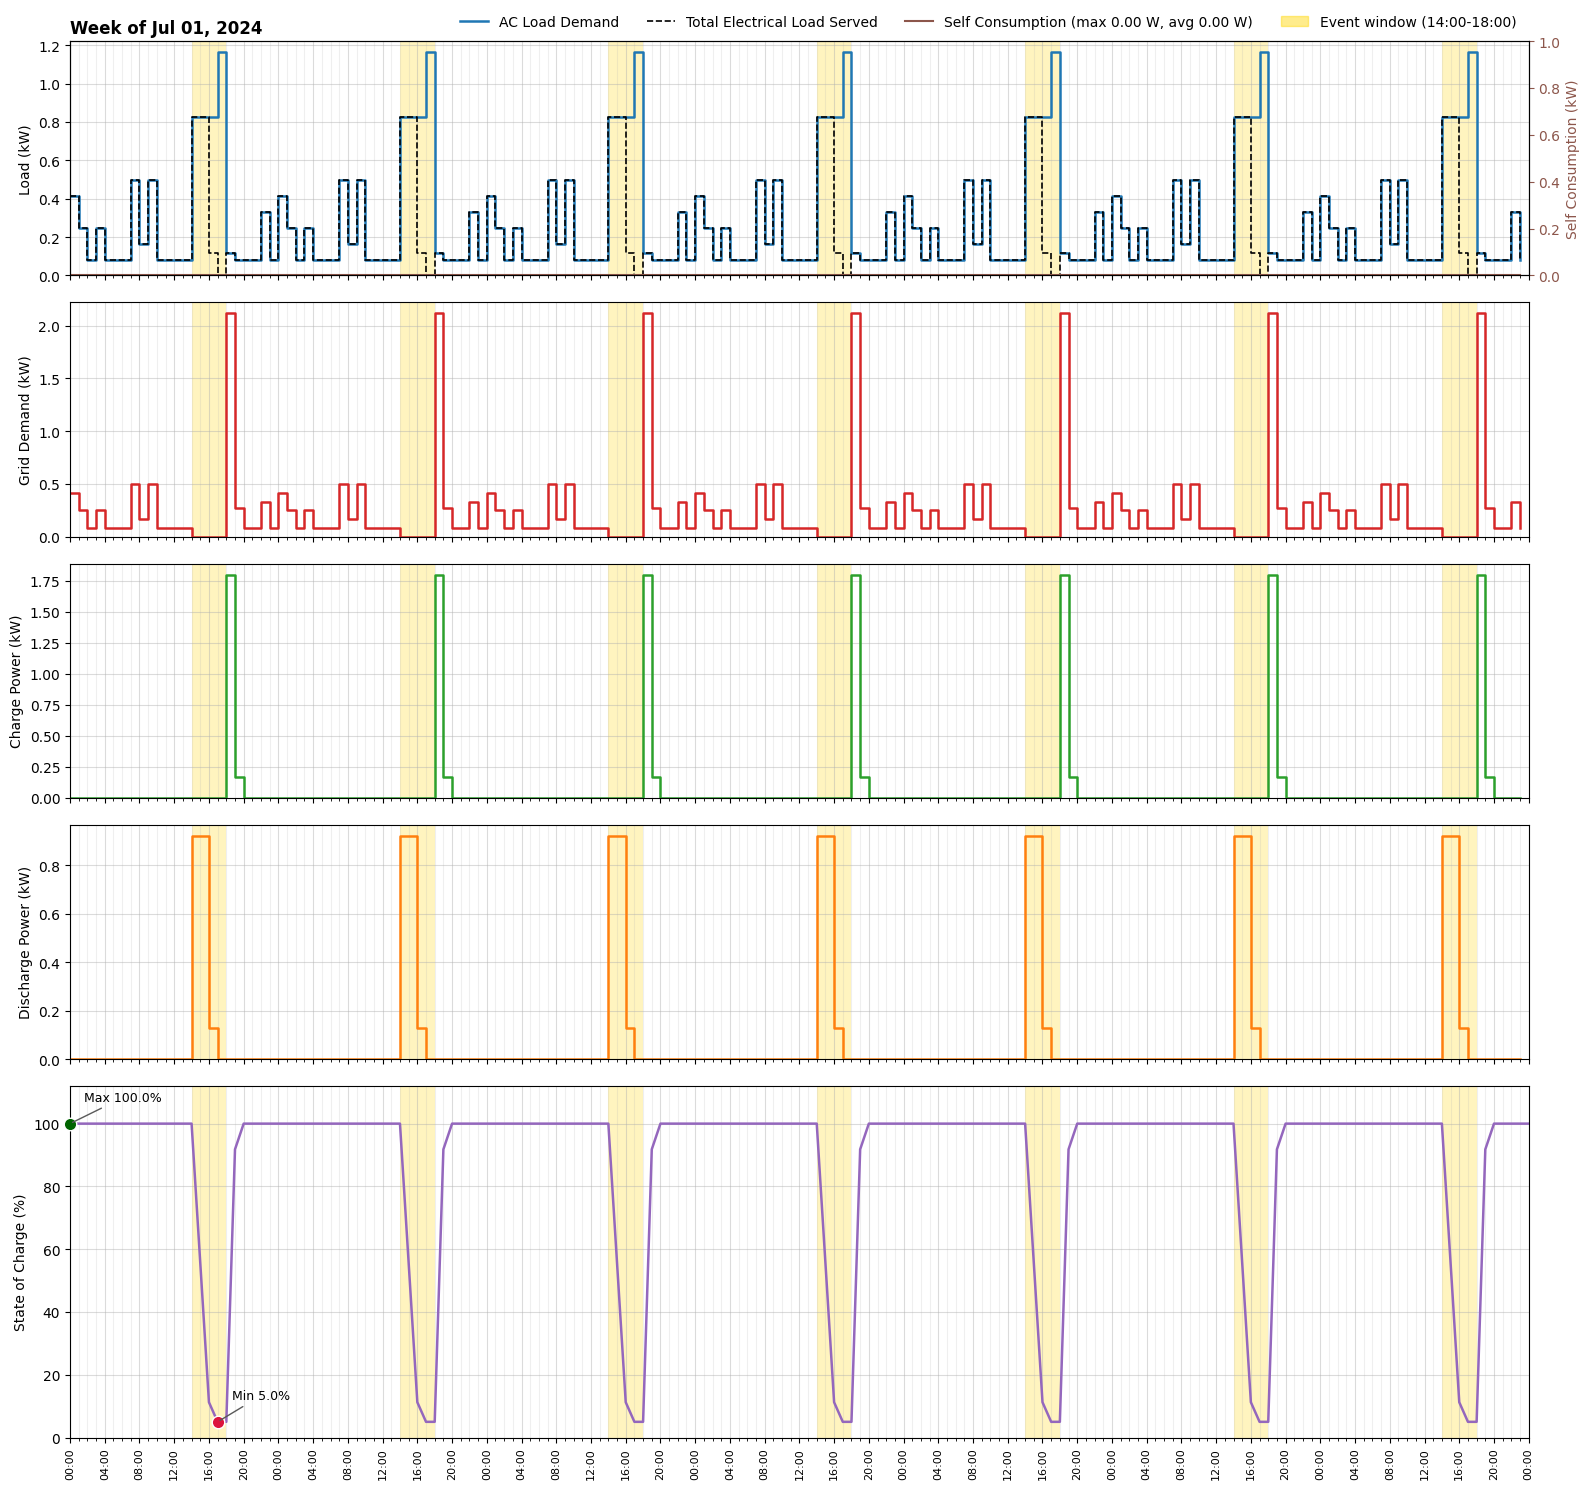

In [775]:
WEEK_START = "2024-07-01"   # change to view a different week
TICK_HOURS = 4              # labeled tick spacing (hours); gridlines are always hourly
SHIFT_SOC_TO_HOUR_END = True    # True: plot each SoC at the END of its hour (how HOMER reports it); False: at the start
SELF_CONSUMPTION_OWN_AXIS = True   # True: right-hand axis (readable at ~9 W); False: same kW axis as the load

soc_col = "Elite 200V2 LFP 2kWh DC Coupled State of Charge"
chg_col = "Elite 200V2 LFP 2kWh DC Coupled Charge Power"
dis_col = "Elite 200V2 LFP 2kWh DC Coupled Discharge Power"
grid_col = "Grid Purchases"   # kW imported from the grid = grid demand

start = pd.Timestamp(WEEK_START)
wk = df.loc[start : start + pd.Timedelta(days=7) - pd.Timedelta(hours=1)]

fig, axes = plt.subplots(5, 1, figsize=(16, 15), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1, 1, 1, 1.5]})

# 1) Loads: demand vs. what was served (they differ when the battery runs out during an event)
axes[0].plot(wk.index, wk["AC Primary Load"], drawstyle="steps-post", lw=1.8, label="AC Load Demand")
axes[0].plot(wk.index, wk["Total Electrical Load Served"], drawstyle="steps-post", lw=1.2, ls="--", color="k", label="Total Electrical Load Served")
axes[0].set(ylabel="Load (kW)")
axes[0].set_title(f"Week of {start:%b %d, %Y}", loc="left", fontweight="bold")

# Self consumption = the DC standby load (Deferrable Load Served) -- only if this export has it
sc_handles = []
if "Deferrable Load Served" in wk.columns:
    sc = wk["Deferrable Load Served"]
    sc_label = f"Self Consumption (max {df['Deferrable Load Served'].max() * 1000:.2f} W, avg {df['Deferrable Load Served'].mean() * 1000:.2f} W)"
    sc_color = "tab:brown"
    if SELF_CONSUMPTION_OWN_AXIS:
        ax_sc = axes[0].twinx()
        ax_sc.plot(wk.index, sc, drawstyle="steps-post", color=sc_color, lw=1.5, label=sc_label)
        ax_sc.set_ylim(0, sc.max() * 1.5 if sc.max() > 0 else 1)
        ax_sc.set_ylabel("Self Consumption (kW)", color=sc_color)
        ax_sc.tick_params(axis="y", colors=sc_color)
        sc_handles = ax_sc.get_lines()
    else:
        axes[0].plot(wk.index, sc, drawstyle="steps-post", color=sc_color, lw=1.5, label=sc_label)

# 2) Grid demand (Grid Purchases)
axes[1].plot(wk.index, wk[grid_col], drawstyle="steps-post", color="tab:red", lw=1.8)
axes[1].set(ylabel="Grid Demand (kW)")

# 3) Charge power
axes[2].plot(wk.index, wk[chg_col], drawstyle="steps-post", color="tab:green", lw=1.8)
axes[2].set(ylabel="Charge Power (kW)")

# 4) Discharge power
axes[3].plot(wk.index, wk[dis_col], drawstyle="steps-post", color="tab:orange", lw=1.8)
axes[3].set(ylabel="Discharge Power (kW)")

# 5) State of charge, with the week's min and max labeled
if SHIFT_SOC_TO_HOUR_END:
    # HOMER's SoC in each row is the value at the END of that hour, so it belongs one hour later on the time axis.
    # Start one row early: the previous row's SoC is the state at the start of the week, so the curve has no gap on the left.
    soc = df[soc_col].loc[start - pd.Timedelta(hours=1) : wk.index[-1]].copy()
    soc.index = soc.index + pd.Timedelta(hours=1)
else:
    soc = wk[soc_col].copy()
axes[4].plot(soc.index, soc, color="tab:purple", lw=1.8)
axes[4].set(ylabel="State of Charge (%)")
axes[4].set_ylim(0, 112)                   # always starts at 0; headroom above 100% for the Max label
axes[4].set_yticks(range(0, 101, 20))

if soc.max() == soc.min():                 # flat line (e.g. the battery never cycles): one label instead of two
    extremes = [(soc.idxmax(), "Constant")]
else:
    extremes = [(soc.idxmax(), "Max"), (soc.idxmin(), "Min")]   # first occurrence if tied
for t, kind in extremes:
    v, is_min = soc.loc[t], kind == "Min"
    axes[4].plot(t, v, marker="o", ms=9, mfc={"Max": "darkgreen", "Min": "crimson", "Constant": "gray"}[kind],
                 mec="white", ls="none", zorder=5, clip_on=False)
    frac = (t - soc.index[0]) / (soc.index[-1] - soc.index[0])    # keep labels inside the axes near the edges
    ha = "left" if frac < 0.06 else "right" if frac > 0.94 else "center"
    below = is_min and v > 0.2 * axes[4].get_ylim()[1]            # Min label goes below the dot only if there is room
    if is_min and not below and ha == "center":
        ha = "left"                                               # near the 0 line: put the label up and beside the dot
    dx = {"left": 10, "right": -10, "center": 0}[ha]
    axes[4].annotate(f"{kind} {v:.1f}%", xy=(t, v),
                     xytext=(dx, -14 if below else 14), textcoords="offset points",
                     ha=ha, va="top" if below else "bottom", fontsize=9, #fontweight="bold",
                     arrowprops=dict(arrowstyle="-", color="0.35"),
                     #bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.5", alpha=0.95),
                     zorder=6)

# Shade event windows on every panel (start/end are read from the data)
all_event, event_text = event_info(df)
event = all_event.loc[wk.index]
run_id = (event != event.shift()).cumsum()
for _, g in wk[event].groupby(run_id[event]):
    for ax in axes:
        ax.axvspan(g.index[0], g.index[-1] + pd.Timedelta(hours=1), color="gold", alpha=0.25, lw=0)
for ax in axes[:4]:
    ax.set_ylim(bottom=0)   # y-axes always start at 0
starts = wk.index[event & ~event.shift(fill_value=False)]
print("Event signal:", event_text)
print("Event starts this week:", [t.strftime("%a %H:%M") for t in starts])
if wk[chg_col].max() == 0 and wk[dis_col].max() == 0:
    print("Note: the battery neither charges nor discharges this week.")

extra = []
if all_event.any():
    ev_hours = sorted(df.index[all_event].hour.unique())
    extra = [Patch(color="gold", alpha=0.45, label=f"Event window ({ev_hours[0]:02d}:00-{ev_hours[-1] + 1:02d}:00)")]
axes[0].legend(handles=axes[0].get_lines() + sc_handles + extra,
               loc="lower right", bbox_to_anchor=(1, 1.0), ncol=4, frameon=False)

# X-axis: labeled ticks every TICK_HOURS, hourly gridlines
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=TICK_HOURS))
axes[-1].xaxis.set_minor_locator(mdates.HourLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[-1].tick_params(axis="x", which="major", labelsize=8, labelrotation=90)
axes[-1].set_xlim(wk.index[0], wk.index[-1] + pd.Timedelta(hours=1))

for ax in axes:
    ax.grid(which="minor", axis="x", alpha=0.20)   # hourly
    ax.grid(which="major", axis="both", alpha=0.45)

# # Midnight divider lines on every panel + bold day labels under the time labels
# for day in pd.date_range(start.normalize(), periods=7, freq="D"):
#     if day > wk.index[0]:
#         for ax in axes:
#             ax.axvline(day, color="k", lw=1.2, alpha=0.6)
#     axes[-1].annotate(f"{day:%a %m/%d}", xy=(mdates.date2num(day + pd.Timedelta(hours=12)), 0),
#                       xycoords=("data", "axes fraction"), xytext=(0, -38), textcoords="offset points",
#                       ha="center", va="top", fontweight="bold")

plt.tight_layout()
#fig.savefig(f"july_week_{WEEK_START}_{ts()}.png", dpi=150, bbox_inches="tight")
plt.show()